# Lab 9.1: Image Data Augmentation Practice

**Student Name:** Samiullah Khan  
**Registration Number:** 22JZELE0492  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Lab Overview
This notebook practices image augmentation techniques for computer vision. It uses `ImageDataGenerator` to apply transformations such as rotation, shifting, shearing, zooming, and horizontal flipping, then continues with CNN-related practice using the prepared image dataset.

## Learning Objectives
- Import image preprocessing utilities from TensorFlow/Keras.
- Apply image augmentation using `ImageDataGenerator`.
- Visualize augmented image samples from the training dataset.
- Understand how augmentation improves image model generalization.
- Practice CNN workflow components after augmentation.

## Section 1: Image Augmentation Setup
This section imports image preprocessing tools and defines augmentation settings for corn leaf images.


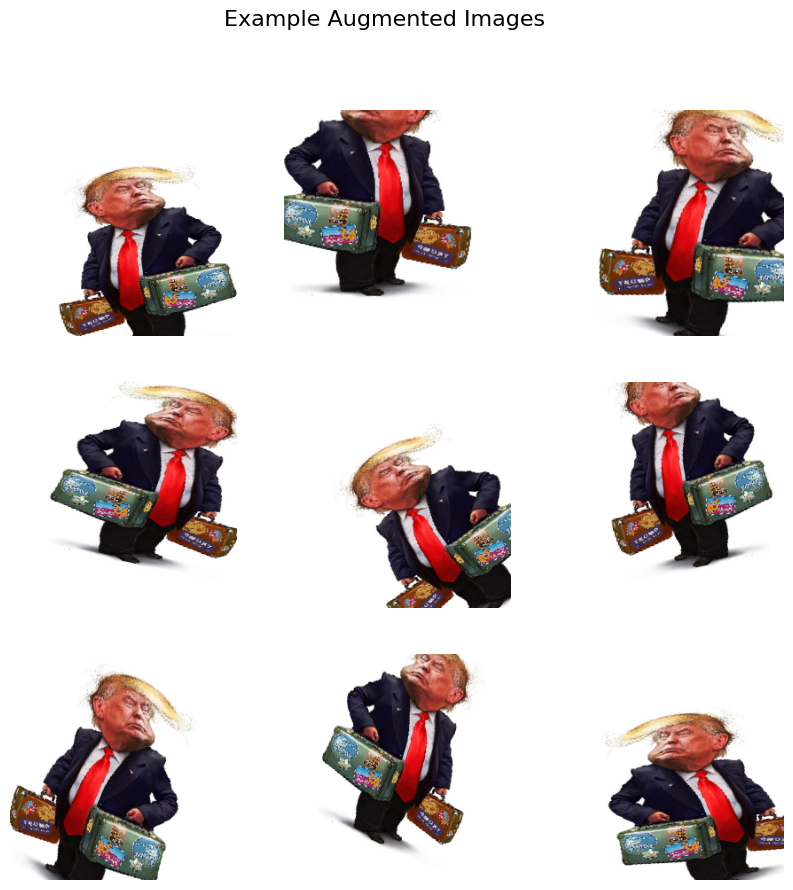

In [17]:
# Import preprocessing, plotting, and array libraries.
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt
import numpy as np

# Define augmentation settings for the sample image.
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Load one sample image for augmentation.
img_path = r"C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\trump.jpg"   
img = load_img(img_path, target_size=(256, 256))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Generate and display nine augmented versions of the image.
plt.figure(figsize=(10, 10))

i = 1
for batch in datagen.flow(img_array, batch_size=1):
    plt.subplot(3, 3, i)
    plt.imshow(batch[0])
    plt.axis("off")
    i += 1
    if i > 9:  # show 9 augmented images
        break

plt.suptitle("Example Augmented Images", fontsize=16)
plt.show()

## Practice

In [18]:
# Import CNN, data-generator, evaluation, plotting, and file-system libraries.
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
import os

In [19]:
# Define the checkpoint filename pattern for model training practice.
checkpoints = r'C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

## Section 2: Augmented Image Visualization
The following cells load sample images and visualize the effect of augmentation transformations.


In [20]:
# Define dataset split folders and select one class folder for augmentation examples.
train_dir = r'C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\Computer vision\sectionB\train'
validation_dir = r'C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\Computer vision\sectionB\validation'
test_dir = r'C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\Computer vision\sectionB\test'
train_Cercospora_dir = os.path.join(train_dir, 'common_rust')

In [21]:
# Configure a general augmentation generator with rotation and horizontal flipping.
datagen = ImageDataGenerator(
                            rotation_range=40,
                            width_shift_range=0,
                            height_shift_range=0,
                            shear_range=0,
                            zoom_range=0,
                            horizontal_flip=True,
                            fill_mode='nearest')

In [22]:
# Configure width-shift augmentation.
datagen = ImageDataGenerator(
                             width_shift_range=0.2)

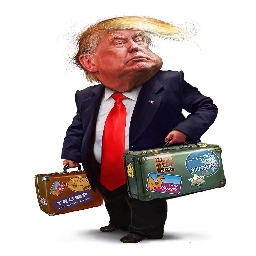

In [23]:
img

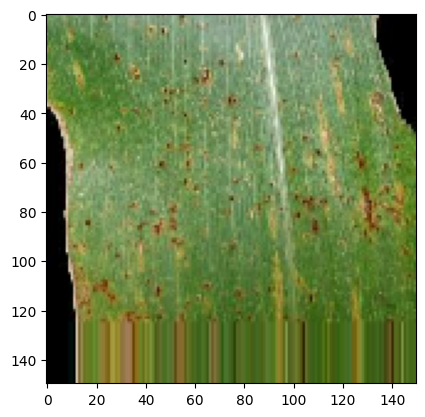

In [24]:
# Load one image and display one width-shifted augmented output.
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 1== 0:
        break
plt.show()

## Section 3: CNN Practice Setup
This section imports CNN model-building tools and defines dataset/checkpoint paths for image classification practice.


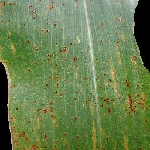

In [25]:
img

In [26]:
# Configure a stronger width-shift augmentation.
datagen = ImageDataGenerator(
                            rotation_range=0,
                            width_shift_range=0.5,
                            height_shift_range=0,
                            shear_range=0,
                            zoom_range=0,
                            horizontal_flip=True,
                            fill_mode='nearest')

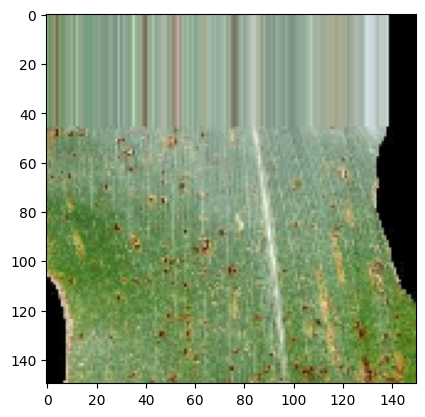

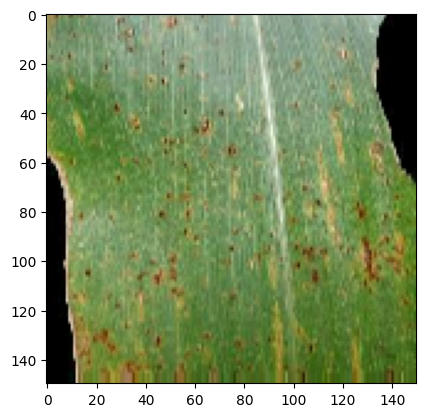

In [27]:
# Load one image and display width-shifted augmented outputs.
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 2== 0:
        break
plt.show()

In [28]:
# Configure height-shift augmentation.
datagen = ImageDataGenerator(
                            rotation_range=0,
                            width_shift_range=0,
                            height_shift_range=0.5,
                            shear_range=0,
                            zoom_range=0,
                            horizontal_flip=True,
                            fill_mode='nearest')

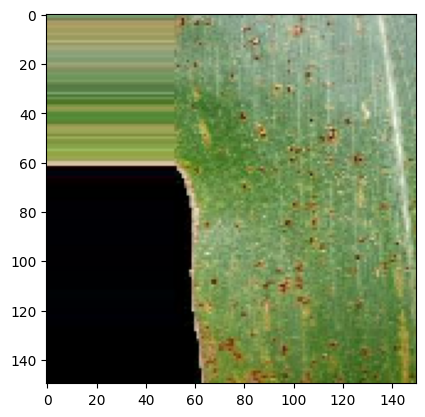

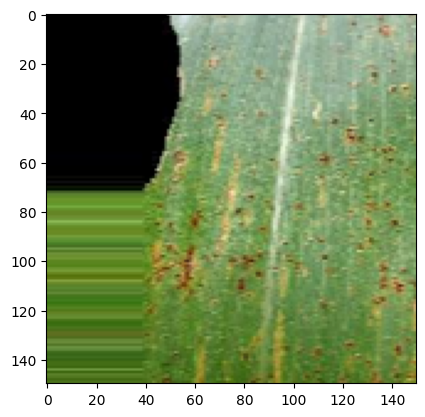

In [29]:
# Load one image and display height-shifted augmented outputs.
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 2== 0:
        break
plt.show()

## Section 4: Training and Evaluation Practice
The remaining cells continue the image classification workflow using generators, model training, prediction, and evaluation utilities.


In [30]:
# Configure zoom augmentation.
datagen = ImageDataGenerator(
                            rotation_range=0,
                            width_shift_range=0,
                            height_shift_range=0,
                            shear_range=0,
                            zoom_range=0.5,
                            horizontal_flip=True,
                            fill_mode='nearest')

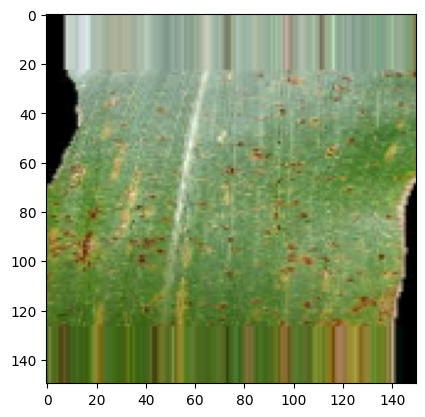

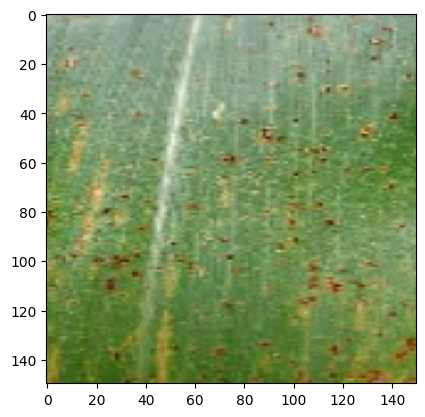

In [31]:
# Load one image and display zoomed augmented outputs.
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 2== 0:
        break
plt.show()

In [32]:
# Configure shear augmentation.
datagen = ImageDataGenerator(
                            rotation_range=0,
                            width_shift_range=0,
                            height_shift_range=0,
                            shear_range=0.5,
                            zoom_range=0,
                            horizontal_flip=True,
                            fill_mode='nearest')

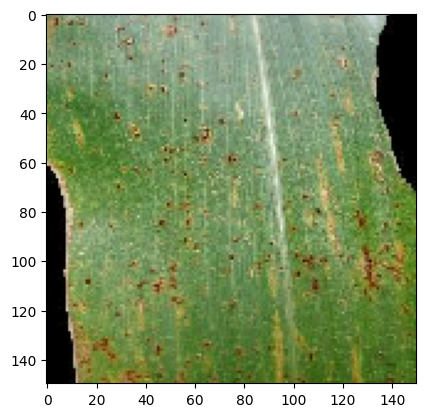

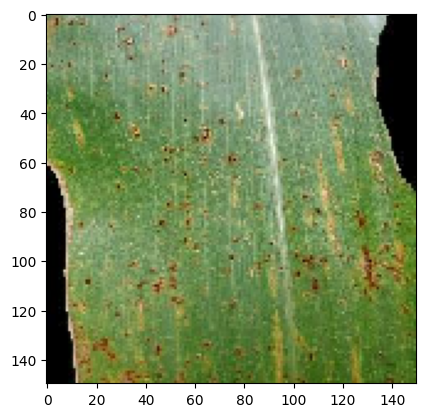

In [33]:
# Load one image and display sheared augmented outputs.
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 2== 0:
        break
plt.show()

## Final Conclusion
In this lab, image augmentation was practiced using Keras `ImageDataGenerator`. These transformations help increase training variety and reduce overfitting in CNN image classification tasks.

## Submitted By
**Student Name:** Samiullah Khan  
**Registration Number:** 22JZELE0492  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus